# TASK 03 — Apply SVD and Reconstruct with Reduced Rank

In this task, we use Singular Value Decomposition (SVD) to decompose a matrix
and reconstruct it using fewer singular values.

The goal is to understand how singular values control how much information
is preserved when we reduce the rank of a matrix.

SVD formula:

M = U Σ Vᵀ

where:
- U contains the left singular vectors
- Σ contains the singular values
- Vᵀ contains the right singular vectors

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Create a 6 × 4 matrix with visible structure.
# Some rows are nearly proportional to each other.

M = np.array([
    [1.0, 2.0, 3.0, 4.0],
    [2.0, 4.0, 6.0, 8.0],
    [3.0, 6.0, 9.0, 12.0],
    [1.0, 2.1, 3.0, 4.1],
    [2.0, 3.9, 6.1, 7.9],
    [4.0, 8.0, 12.0, 16.0]
])

print("Matrix M:")
print(M)

print("\nShape of M:")
print(M.shape)

Matrix M:
[[ 1.   2.   3.   4. ]
 [ 2.   4.   6.   8. ]
 [ 3.   6.   9.  12. ]
 [ 1.   2.1  3.   4.1]
 [ 2.   3.9  6.1  7.9]
 [ 4.   8.  12.  16. ]]

Shape of M:
(6, 4)


In [2]:
# Apply Singular Value Decomposition

U, s, Vt = np.linalg.svd(M, full_matrices=False)

print("U:")
print(U)

print("\nSingular values:")
print(s)

print("\nVt:")
print(Vt)

U:
[[-1.69029375e-01  3.74146804e-02 -5.79874593e-02  9.71855464e-01]
 [-3.38058750e-01  7.48293608e-02 -1.15974919e-01 -2.33278351e-02]
 [-5.07088125e-01  1.12244041e-01 -1.73962378e-01 -2.26160021e-01]
 [-1.72406791e-01  5.18828947e-01  8.37312619e-01  3.26590036e-14]
 [-3.36374807e-01 -8.29952272e-01  4.45006983e-01  2.70153129e-14]
 [-6.76117500e-01  1.49658722e-01 -2.31949837e-01 -6.16799327e-02]]

Singular values:
[3.24039607e+01 1.81131362e-01 2.28583302e-02 8.71977503e-16]

Vt:
[[-1.82571436e-01 -3.64636861e-01 -5.48752376e-01 -7.29779734e-01]
 [-1.02882152e-01  5.38878261e-01 -7.66851077e-01  3.33113958e-01]
 [-5.37974225e-01  6.40299549e-01  3.32881744e-01 -4.35648901e-01]
 [-8.16496581e-01 -4.08248290e-01  3.88914061e-16  4.08248290e-01]]


In [3]:
print("Shape of M :", M.shape)
print("Shape of U :", U.shape)
print("Shape of s :", s.shape)
print("Shape of Vt:", Vt.shape)

Shape of M : (6, 4)
Shape of U : (6, 4)
Shape of s : (4,)
Shape of Vt: (4, 4)


### What does full_matrices=False do?

For an m × n matrix, a full SVD can produce:

U  → m × m
Σ  → m × n
Vᵀ → n × n

When `full_matrices=False`, NumPy produces the reduced SVD:

U  → m × r
Σ  → r × r
Vᵀ → r × n

where:

r = min(m, n)

For our 6 × 4 matrix:

U  → 6 × 4
Σ  → 4 × 4
Vᵀ → 4 × 4

We want this form because it contains everything necessary for reconstruction
while avoiding unnecessary extra columns in U.

In [4]:
Sigma = np.diag(s)

print("Singular values:")
print(s)

print("\nSigma:")
print(Sigma)

print("\nShape of Sigma:")
print(Sigma.shape)

Singular values:
[3.24039607e+01 1.81131362e-01 2.28583302e-02 8.71977503e-16]

Sigma:
[[3.24039607e+01 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.81131362e-01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 2.28583302e-02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 8.71977503e-16]]

Shape of Sigma:
(4, 4)


In [5]:
# Reconstruct the original matrix using all singular values

M_reconstructed = U @ Sigma @ Vt

print("Original matrix:")
print(M)

print("\nReconstructed matrix:")
print(M_reconstructed)

Original matrix:
[[ 1.   2.   3.   4. ]
 [ 2.   4.   6.   8. ]
 [ 3.   6.   9.  12. ]
 [ 1.   2.1  3.   4.1]
 [ 2.   3.9  6.1  7.9]
 [ 4.   8.  12.  16. ]]

Reconstructed matrix:
[[ 1.   2.   3.   4. ]
 [ 2.   4.   6.   8. ]
 [ 3.   6.   9.  12. ]
 [ 1.   2.1  3.   4.1]
 [ 2.   3.9  6.1  7.9]
 [ 4.   8.  12.  16. ]]


In [6]:
# Check whether the reconstructed matrix is approximately
# equal to the original matrix.

print("Does the reconstruction match the original?")
print(np.allclose(M, M_reconstructed))

Does the reconstruction match the original?
True


In [8]:
def rank_k(k):
    """
    Reconstruct M using only the top k singular values.
    """
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

In [9]:
M_rank1 = rank_k(1)

print("Rank-1 approximation:")
print(M_rank1)

Rank-1 approximation:
[[ 0.99998415  1.99719675  3.00563816  3.99716504]
 [ 1.99996829  3.9943935   6.01127632  7.99433009]
 [ 2.99995244  5.99159026  9.01691449 11.99149513]
 [ 1.01996507  2.03710322  3.06569453  4.07703335]
 [ 1.99000602  3.97449658  5.98133287  7.95450862]
 [ 3.99993659  7.98878701 12.02255265 15.98866018]]


In [10]:
error_rank1 = np.linalg.norm(M - M_rank1) / np.linalg.norm(M)

print("Rank-1 relative error:", error_rank1)

Rank-1 relative error: 0.005634036569226535


In [12]:
M_rank2 = rank_k(2)

error_rank2 = np.linalg.norm(M - M_rank2) / np.linalg.norm(M)

print("Rank-2 approximation:")
print(M_rank2)

print("\nRank-2 relative error:", error_rank2)

Rank-2 approximation:
[[ 0.99928692  2.00084871  3.00044123  3.99942255]
 [ 1.99857383  4.00169743  6.00088247  7.9988451 ]
 [ 2.99786075  6.00254614  9.0013237  11.99826765]
 [ 1.01029659  2.08774494  2.99362879  4.10833813]
 [ 2.00547234  3.8934868   6.09661389  7.90443147]
 [ 3.99714767  8.00339486 12.00176493 15.9976902 ]]

Rank-2 relative error: 0.0007054065910608907


In [13]:
M_rank3 = rank_k(3)

error_rank3 = np.linalg.norm(M - M_rank3) / np.linalg.norm(M)

print("Rank-3 approximation:")
print(M_rank3)

print("\nRank-3 relative error:", error_rank3)

Rank-3 approximation:
[[ 1.   2.   3.   4. ]
 [ 2.   4.   6.   8. ]
 [ 3.   6.   9.  12. ]
 [ 1.   2.1  3.   4.1]
 [ 2.   3.9  6.1  7.9]
 [ 4.   8.  12.  16. ]]

Rank-3 relative error: 2.311820259511712e-16


In [14]:
errors = []

for k in [1, 2, 3]:
    approximation = rank_k(k)
    error = np.linalg.norm(M - approximation) / np.linalg.norm(M)
    errors.append(error)

print("Relative reconstruction errors:")
print(f"Rank 1: {errors[0]:.6f}")
print(f"Rank 2: {errors[1]:.6f}")
print(f"Rank 3: {errors[2]:.6f}")

Relative reconstruction errors:
Rank 1: 0.005634
Rank 2: 0.000705
Rank 3: 0.000000


In [15]:
print("======================================")
print("       SVD REDUCED-RANK RESULTS")
print("======================================")

for k, error in zip([1, 2, 3], errors):
    print(f"Rank-{k} relative error: {error:.6f}")

       SVD REDUCED-RANK RESULTS
Rank-1 relative error: 0.005634
Rank-2 relative error: 0.000705
Rank-3 relative error: 0.000000


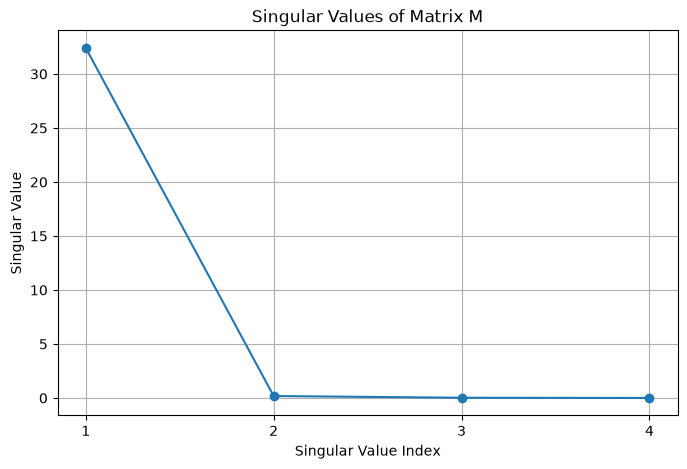

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(s) + 1),
    s,
    marker="o"
)

plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.title("Singular Values of Matrix M")

plt.xticks(range(1, len(s) + 1))
plt.grid(True)

plt.show()

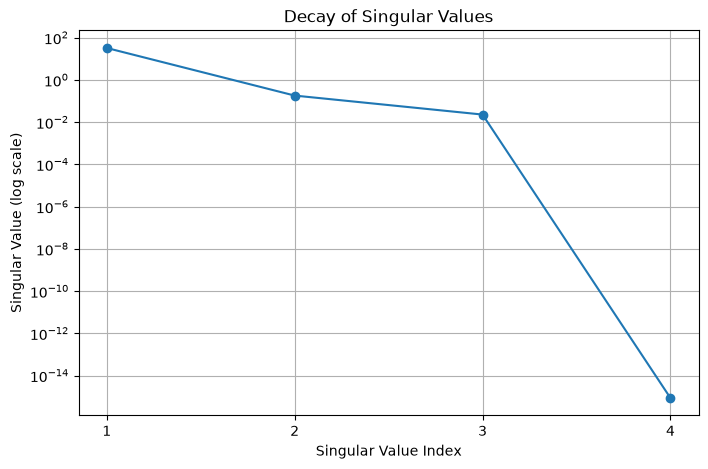

In [17]:
plt.figure(figsize=(8, 5))

plt.semilogy(
    range(1, len(s) + 1),
    s,
    marker="o"
)

plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value (log scale)")
plt.title("Decay of Singular Values")

plt.xticks(range(1, len(s) + 1))
plt.grid(True)

plt.show()

In [18]:
print("Singular values:")
for i, value in enumerate(s, start=1):
    print(f"σ{i} = {value:.6f}")

Singular values:
σ1 = 32.403961
σ2 = 0.181131
σ3 = 0.022858
σ4 = 0.000000


In [19]:
# Calculate the percentage of total squared singular-value energy
# captured by each singular value.

energy = s**2
energy_percentage = 100 * energy / np.sum(energy)

for i, percentage in enumerate(energy_percentage, start=1):
    print(f"Singular value {i}: {percentage:.2f}%")

Singular value 1: 100.00%
Singular value 2: 0.00%
Singular value 3: 0.00%
Singular value 4: 0.00%


In [20]:
cumulative_energy = np.cumsum(energy_percentage)

print("Cumulative information retained:")

for i, percentage in enumerate(cumulative_energy, start=1):
    print(f"Top {i} singular value(s): {percentage:.2f}%")

Cumulative information retained:
Top 1 singular value(s): 100.00%
Top 2 singular value(s): 100.00%
Top 3 singular value(s): 100.00%
Top 4 singular value(s): 100.00%


### Observation

The singular values are ordered from largest to smallest.

If the singular values decrease rapidly, most of the important information
in the matrix is concentrated in the first few singular values.

This means that the matrix can be represented accurately using fewer
singular values, making it highly compressible.

If the singular values decrease slowly, more singular values are required
to accurately reconstruct the matrix, so the matrix is less compressible.

### Why are singular values returned largest-first?

NumPy returns singular values in descending order:

σ1 ≥ σ2 ≥ σ3 ≥ ...

The largest singular value represents the strongest direction of the matrix.
The next singular values represent progressively weaker directions.

Therefore, when we keep the first k singular values, we keep the most
important information first.

This is why reduced-rank approximation uses:

s[:k]

### What does a sharp drop in singular values tell us?

If the singular values drop sharply after the third singular value, it means
that most of the matrix's information is contained in the first three
directions.

Therefore, the matrix has an effective or approximate rank of about 3.

The exact mathematical rank may still be higher because very small
singular values can be non-zero, but the matrix behaves approximately like
a rank-3 matrix.

### Connection between singular values and compression

A matrix is highly compressible when its singular values decay rapidly because most of its information can be represented accurately using only a few of the largest singular values.

In [21]:
print("==============================================")
print("           TASK 03 FINAL VERIFICATION")
print("==============================================")

print("\nOriginal matrix shape:", M.shape)

print("\nSVD shapes:")
print("U :", U.shape)
print("s :", s.shape)
print("Vt:", Vt.shape)

print("\nFull reconstruction matches original:",
      np.allclose(M, M_reconstructed))

print("\nRelative errors:")
print(f"Rank-1: {error_rank1:.6f}")
print(f"Rank-2: {error_rank2:.6f}")
print(f"Rank-3: {error_rank3:.6f}")

print("\nSingular values:")
print(s)

           TASK 03 FINAL VERIFICATION

Original matrix shape: (6, 4)

SVD shapes:
U : (6, 4)
s : (4,)
Vt: (4, 4)

Full reconstruction matches original: True

Relative errors:
Rank-1: 0.005634
Rank-2: 0.000705
Rank-3: 0.000000

Singular values:
[3.24039607e+01 1.81131362e-01 2.28583302e-02 8.71977503e-16]
